In [22]:
# Island similarity via GRM — compute inter-island relatedness weights
# Formula: w_j = mean(G[i in I_test, k in I_j]) / sum_m mean(G[i in I_test, k in I_m])

import os
import json
import numpy as np
import pandas as pd

from src.data import load_data

# Load config for consistent paths
CONFIG_PATH = "config_nested.json"
include_islands = [20,22,23,24,26,27,28,33,34,35,38]
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = json.load(f)

paths = cfg["base_train"]["paths"].copy()
# Ensure only the needed keys are present
paths = {
    k: v for k, v in paths.items()
    if k in {"npz", "npz_path", "snp_feather", "phenotype_csv", "grm_rds"}
}

# Load data with GRM and locality
X, y, ids, GRM_df, locality_codes, code_to_label, y_eval = load_data(
    paths,
    target_column=cfg["base_train"].get("target_column", "y_adjusted"),
    standardize_features=cfg["base_train"].get("standardize_features", False),
    return_locality=True,
    return_eval=True,
    eval_target_column=cfg["base_train"].get("eval_target_column", None),
    min_count=20
)

# Build mapping from island label to indices
labels = [code_to_label[int(c)] for c in locality_codes]
labels = np.asarray(labels)
unique_islands = sorted(np.unique(labels), key=lambda s: int(s) if s.isdigit() else s)

# Filter to include_islands (preserve provided order when displaying)
allowed = set(str(i) for i in include_islands)
selected_islands = [isl for isl in unique_islands if isl in allowed]

island_to_idx = {isl: np.where(labels == isl)[0] for isl in selected_islands}

print(f"Loaded: {len(ids)} samples, {len(selected_islands)} islands (filtered). GRM shape = {GRM_df.shape}")

Loaded: 5650 samples, 11 islands (filtered). GRM shape = (5650, 5650)


In [37]:
# Functions to compute inter-island relatedness means and weights
from typing import Dict, Tuple


def mean_relatedness_between(G: pd.DataFrame, idx_a: np.ndarray, idx_b: np.ndarray) -> float:
    if len(idx_a) == 0 or len(idx_b) == 0:
        return np.nan
    # Use DataFrame iloc to preserve correct alignment
    sub = G.values[np.ix_(idx_a, idx_b)]
    return float(np.nanmean(sub))


def _softmax(x: np.ndarray, tau: float = 1.0) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if not np.isfinite(x).all():
        # replace non-finite with min finite value to avoid NaNs
        finite = x[np.isfinite(x)]
        fill = finite.min() if finite.size else 0.0
        x = np.where(np.isfinite(x), x, fill)
    # Numerical stability
    x_stable = (x - np.max(x)) / max(tau, 1e-8)
    e = np.exp(x_stable)
    s = e.sum()
    return e / s if s != 0 else np.full_like(x, np.nan)


def compute_weights_for_test_island(
    G: pd.DataFrame,
    island_to_idx: Dict[str, np.ndarray],
    test_island: str,
    *,
    exclude_self: bool = False,
    method: str = "normalize",  # "normalize" (mean/sum) or "softmax"
    temperature: float = 1.0,
) -> pd.DataFrame:
    """
    Returns DataFrame with columns: island_j, mean_relatedness, weight
    - normalize: w_j = mean(G[i in I_test, k in I_j]) / sum_m mean(G[i in I_test, k in I_m])
    - softmax:   w_j = softmax(mean_relatedness_j / temperature)
    If exclude_self=True, j != test_island is omitted from both numerator and denominator.
    """
    idx_test = island_to_idx[test_island]
    means = []
    for j, idx_j in island_to_idx.items():
        if exclude_self and j == test_island:
            continue
        m = mean_relatedness_between(G, idx_test, idx_j)
        means.append((j, m))
    df = pd.DataFrame(means, columns=["island_j", "mean_relatedness"]).dropna()

    if method == "softmax":
        df["weight"] = _softmax(df["mean_relatedness"].to_numpy(), tau=temperature)
    else:
        denom = df["mean_relatedness"].sum()
        df["weight"] = df["mean_relatedness"] / (denom if denom != 0 else np.nan)

    df.insert(0, "test_island", test_island)
    return df


def compute_weight_matrix(
    G: pd.DataFrame,
    island_to_idx: Dict[str, np.ndarray],
    *,
    exclude_self: bool = False,
    method: str = "normalize",
    temperature: float = 1.0,
) -> pd.DataFrame:
    """Compute weights for every test island against all j, return a long DataFrame and a wide pivot."""
    frames = []
    for test in island_to_idx.keys():
        frames.append(
            compute_weights_for_test_island(
                G, island_to_idx, test, exclude_self=exclude_self, method=method, temperature=temperature
            )
        )
    long_df = pd.concat(frames, ignore_index=True)

    # Prefer include_islands order if available; otherwise fallback to sorted
    try:
        order = [s for s in [str(i) for i in include_islands] if s in island_to_idx.keys()]
        if not order:
            order = sorted(island_to_idx.keys(), key=lambda s: int(s) if s.isdigit() else s)
    except NameError:
        order = sorted(island_to_idx.keys(), key=lambda s: int(s) if s.isdigit() else s)

    wide_df = (
        long_df
        .pivot(index="test_island", columns="island_j", values="weight")
        .reindex(index=order, columns=order)
    )
    return long_df, wide_df

print("Functions ready (supports method='normalize' or 'softmax').")

Functions ready (supports method='normalize' or 'softmax').


In [59]:
# Compute and save weights
EXCLUDE_SELF = True  # set True to exclude test island from normalization
USE_SOFTMAX = True   # if False, falls back to mean/sum normalization
TEMPERATURE = 0.003    # softmax temperature (lower => peakier); only used if USE_SOFTMAX

method = "softmax" if USE_SOFTMAX else "normalize"
long_df, wide_df = compute_weight_matrix(
    GRM_df,
    island_to_idx,
    exclude_self=EXCLUDE_SELF,
    method=method,
    temperature=TEMPERATURE,
)

# Order by include_islands (fallback to current order if not present)
order = [str(i) for i in include_islands if str(i) in wide_df.index]
if not order:
    order = list(wide_df.index)
wide_df = wide_df.loc[order, order]

print(f"Weights ({method}, tau={TEMPERATURE}) — row = test island, col = island j")
display(wide_df.round(4))

os.makedirs("outputs", exist_ok=True)
out_csv_long = os.path.join(
    "outputs",
    f"inter_island_relatedness_weights_long_method_{method}_tau_{TEMPERATURE}_exclself_{EXCLUDE_SELF}.csv",
)
out_csv_wide = os.path.join(
    "outputs",
    f"inter_island_relatedness_weights_wide_method_{method}_tau_{TEMPERATURE}_exclself_{EXCLUDE_SELF}.csv",
)
wide_df.to_csv(out_csv_wide)
long_df.to_csv(out_csv_long, index=False)

print(f"Saved: \n - {out_csv_wide}\n - {out_csv_long}")

Weights (softmax, tau=0.003) — row = test island, col = island j


island_j,20,22,23,24,26,27,28,33,34,35,38
test_island,,,,,,,,,,,
20,NaN,0.2878,0.0869,0.0936,0.1160,0.1390,0.0537,0.0752,0.0706,0.0510,0.0260
22,0.0066,NaN,0.1186,0.8547,0.0006,0.0012,0.0010,0.0017,0.0121,0.0033,0.0002
23,0.0029,0.1714,NaN,0.7424,0.0006,0.0009,0.0018,0.0024,0.0595,0.0180,0.0002
24,0.0015,0.6135,0.3688,NaN,0.0003,0.0005,0.0006,0.0010,0.0101,0.0035,0.0002
26,0.2000,0.0479,0.0286,0.0363,NaN,0.2599,0.2358,0.0584,0.0284,0.0245,0.0802
27,0.2098,0.0768,0.0408,0.0477,0.2276,NaN,0.1827,0.1155,0.0397,0.0357,0.0238
28,0.0694,0.0566,0.0680,0.0496,0.1767,0.1563,NaN,0.1681,0.0904,0.1467,0.0182
33,0.0512,0.0489,0.0483,0.0392,0.0231,0.0521,0.0886,NaN,0.1496,0.4676,0.0315
34,0.0013,0.0100,0.0341,0.0117,0.0003,0.0005,0.0013,0.0042,NaN,0.9364,0.0002


Saved: 
 - outputs\inter_island_relatedness_weights_wide_method_softmax_tau_0.003_exclself_True.csv
 - outputs\inter_island_relatedness_weights_long_method_softmax_tau_0.003_exclself_True.csv


In [53]:
# Mean inter-island relatedness (no normalization)
import numpy as np
import pandas as pd


def compute_mean_relatedness_matrix(G: pd.DataFrame, island_to_idx: dict) -> pd.DataFrame:
    # Prefer include_islands order if available; otherwise fallback to sorted
    try:
        islands = [s for s in [str(i) for i in include_islands] if s in island_to_idx.keys()]
        if not islands:
            islands = sorted(island_to_idx.keys(), key=lambda s: int(s) if str(s).isdigit() else s)
    except NameError:
        islands = sorted(island_to_idx.keys(), key=lambda s: int(s) if str(s).isdigit() else s)

    mat = pd.DataFrame(index=islands, columns=islands, dtype=float)
    Gv = G.values  # speed
    for a in islands:
        ia = island_to_idx[a]
        for b in islands:
            ib = island_to_idx[b]
            sub = Gv[np.ix_(ia, ib)]
            mat.loc[a, b] = float(np.nanmean(sub))
    return mat

mean_mat = compute_mean_relatedness_matrix(GRM_df, island_to_idx)

# Inter-island only view (diagonal excluded)
inter_only = mean_mat.copy()
for i in range(len(inter_only)):
    inter_only.iat[i, i] = np.nan

print("Mean inter-island relatedness (row = test island, col = island j) — diagonal = NaN")
display(inter_only.round(4))

os.makedirs("outputs", exist_ok=True)
path_full = os.path.join("outputs", "inter_island_mean_relatedness.csv")
path_inter = os.path.join("outputs", "inter_island_mean_relatedness_offdiag_nan.csv")
mean_mat.to_csv(path_full)
inter_only.to_csv(path_inter)
print(f"Saved: \n - {path_full}\n - {path_inter}")

Mean inter-island relatedness (row = test island, col = island j) — diagonal = NaN


,20,22,23,24,26,27,28,33,34,35,38
20,NaN,0.0066,0.0031,0.0033,0.0039,0.0045,0.0016,0.0026,0.0024,0.0015,-0.0006
22,0.0066,NaN,0.0153,0.0212,-0.0004,0.0014,0.0010,0.0025,0.0084,0.0045,-0.0035
23,0.0031,0.0153,NaN,0.0197,-0.0019,-0.0004,0.0016,0.0024,0.0121,0.0085,-0.0050
24,0.0033,0.0212,0.0197,NaN,-0.0012,0.0000,0.0006,0.0018,0.0089,0.0057,-0.0034
26,0.0039,-0.0004,-0.0019,-0.0012,NaN,0.0047,0.0044,0.0002,-0.0019,-0.0024,0.0012
27,0.0045,0.0014,-0.0004,0.0000,0.0047,NaN,0.0040,0.0027,-0.0005,-0.0009,-0.0021
28,0.0016,0.0010,0.0016,0.0006,0.0044,0.0040,NaN,0.0043,0.0024,0.0039,-0.0024
33,0.0026,0.0025,0.0024,0.0018,0.0002,0.0027,0.0043,NaN,0.0058,0.0093,0.0012
34,0.0024,0.0084,0.0121,0.0089,-0.0019,-0.0005,0.0024,0.0058,NaN,0.0221,-0.0038
35,0.0015,0.0045,0.0085,0.0057,-0.0024,-0.0009,0.0039,0.0093,0.0221,NaN,-0.0047


Saved: 
 - outputs\inter_island_mean_relatedness.csv
 - outputs\inter_island_mean_relatedness_offdiag_nan.csv


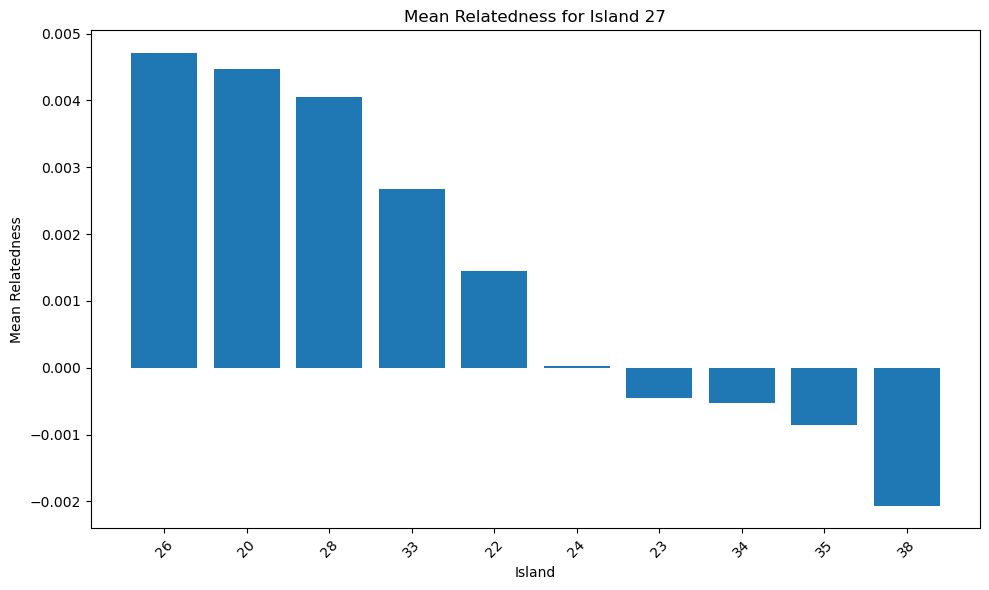

In [58]:
focus_island = 27

# barplot of relatedness for focus island
import matplotlib.pyplot as plt
df_focus = inter_only.loc[str(focus_island)].dropna().reset_index()
df_focus.columns = ['island', 'mean_relatedness']
df_focus = df_focus.sort_values(by='mean_relatedness', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(df_focus['island'], df_focus['mean_relatedness'])
plt.xlabel('Island')
plt.ylabel('Mean Relatedness')
plt.title(f'Mean Relatedness for Island {focus_island}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

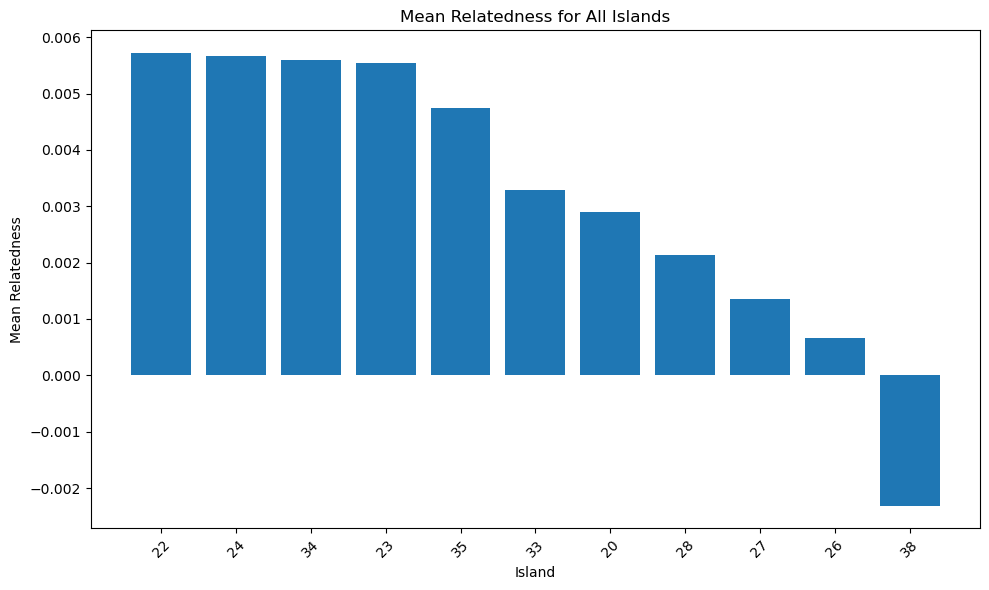

In [55]:
# bar plot of mean mean for all islands
mean_means = inter_only.mean(axis=1).reset_index()
mean_means.columns = ['island', 'mean_relatedness']
mean_means = mean_means.sort_values(by='mean_relatedness', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(mean_means['island'], mean_means['mean_relatedness'])
plt.xlabel('Island')
plt.ylabel('Mean Relatedness')
plt.title('Mean Relatedness for All Islands')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()